In [19]:
import os
os.environ['KAGGLE_USERNAME'] = 'prayushkhadkaaa'
os.environ['KAGGLE_KEY'] = 'KGAT_314b60a43391bd79af31d80c5a711a08'

In [20]:
#downloading the dataest
!kaggle datasets download -d ademboukhris/cars-body-type-cropped

Dataset URL: https://www.kaggle.com/datasets/ademboukhris/cars-body-type-cropped
License(s): CC0-1.0
100% 1.34G/1.34G [00:15<00:00, 93.4MB/s]



In [21]:
!ls -la

total 1406608
drwxr-xr-x 1 root root       4096 Jun 28 09:17 .
drwxr-xr-x 1 root root       4096 Jun 28 07:43 ..
-rw-r--r-- 1 root root 1440306509 Jun 16  2023 cars-body-type-cropped.zip
drwxr-xr-x 4 root root       4096 Jun  4 13:32 .config
drwx------ 5 root root       4096 Jun 28 08:35 drive
drwxr-xr-x 2 root root       4096 Jun 28 08:41 .gradio
drwxr-xr-x 1 root root       4096 Jun  4 13:32 sample_data
-rw-r--r-- 1 root root      27219 Jun 28 08:39 suv.jpeg


In [22]:
!unzip -q cars-body-type-cropped.zip -d car_dataset

In [23]:
print(os.listdir('car_dataset'))

['Cars_Body_Type']


In [24]:
print(os.listdir('car_dataset/Cars_Body_Type'))

['train', 'valid', 'test']


In [25]:
print(os.listdir('car_dataset/Cars_Body_Type/train'))

['Sedan', 'Hatchback', 'Convertible', 'SUV', 'VAN', 'Coupe', 'Pick-Up']


In [26]:
import shutil

unwanted = ['VAN', 'Pick-Up']
splits = ['train', 'valid', 'test']

for split in splits:
    for cls in unwanted:
        path = f'car_dataset/Cars_Body_Type/{split}/{cls}'
        shutil.rmtree(path)

In [27]:
print(os.listdir('car_dataset/Cars_Body_Type/train'))

['Sedan', 'Hatchback', 'Convertible', 'SUV', 'Coupe']


In [28]:
import torchvision.transforms as transforms

transform= transforms.Compose([
    transforms.Resize((224,224)),  #224 cause ResNet was trained on imagenet using 224x224 inputs
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [29]:
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

train_dataset= ImageFolder('car_dataset/Cars_Body_Type/train', transform=transform)
valid_dataset= ImageFolder('car_dataset/Cars_Body_Type/valid', transform=transform)
test_dataset=  ImageFolder('car_dataset/Cars_Body_Type/test',  transform=transform)


In [30]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [31]:
import torchvision.models as models
import torch.nn as nn

resnet=models.resnet18(weights='IMAGENET1K_V1')


#we don't want to change the weights of the hidden layers
for param in resnet.parameters():
  param.requires_grad= False

resnet.fc= nn.Linear(512,5)  #indicates the output layer

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 142MB/s]


In [14]:
import torch.optim as optim

criterion= nn.CrossEntropyLoss()
optimizer=optim.Adam(resnet.fc.parameters(), lr=0.001)

In [15]:
import torch
device= torch.device('cuda' if torch.cuda.is_available() else 'cpu')
resnet.to(device)

num_epochs=8

for epoch in range(num_epochs):  #goes through the entire dataset 8 times
  resnet.train()
  running_loss=0.0

  for images, labels in train_loader:   #goes through a single dataset multiple times based on the batch size
    images,labels= images.to(device), labels.to(device)

    optimizer.zero_grad()
    outputs= resnet(images)
    loss=criterion(outputs,labels)
    loss.backward()
    optimizer.step()

    running_loss+=loss.item()

  print(f'Epoch {epoch+1}/{num_epochs}, Loss: {running_loss/len(train_loader)}')

Epoch 1/8, Loss: 1.2399904449780783
Epoch 2/8, Loss: 0.9046320274472237
Epoch 3/8, Loss: 0.7911281511187553
Epoch 4/8, Loss: 0.7509863741695881
Epoch 5/8, Loss: 0.6898714246849219
Epoch 6/8, Loss: 0.6696784282724063
Epoch 7/8, Loss: 0.6390480657418569
Epoch 8/8, Loss: 0.6311803678671519


In [16]:
torch.save(resnet.state_dict(), 'car_classifier_resnet18.pth')

In [35]:
resnet.load_state_dict(torch.load('/content/drive/MyDrive/car_classifier_resnet18.pth', map_location=torch.device('cpu')))
resnet.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [18]:
from google.colab import drive
drive.mount('/content/drive')

import shutil
shutil.copy('car_classifier_resnet18.pth','/content/drive/MyDrive/car_classifier_resnet18.pth')

Mounted at /content/drive


'/content/drive/MyDrive/car_classifier_resnet18.pth'

In [19]:
import os
print(os.path.getsize('/content/drive/MyDrive/car_classifier_resnet18.pth'))

44797643


In [36]:
correct=0
total=0

with torch.no_grad(): #we don't need gradients for evaluation
  for images, labels in valid_loader:
    images,labels= images.to(device), labels.to(device)
    outputs= resnet(images)
    _, predicted = torch.max(outputs,1)
    total+= labels.size(0)
    correct+=(predicted== labels).sum().item()

accuracy= 100* correct/total
print(f"Validation Accuracy: {accuracy:.2f}%")

Validation Accuracy: 75.34%


In [34]:
print(valid_dataset.classes)

['Convertible', 'Coupe', 'Hatchback', 'SUV', 'Sedan']


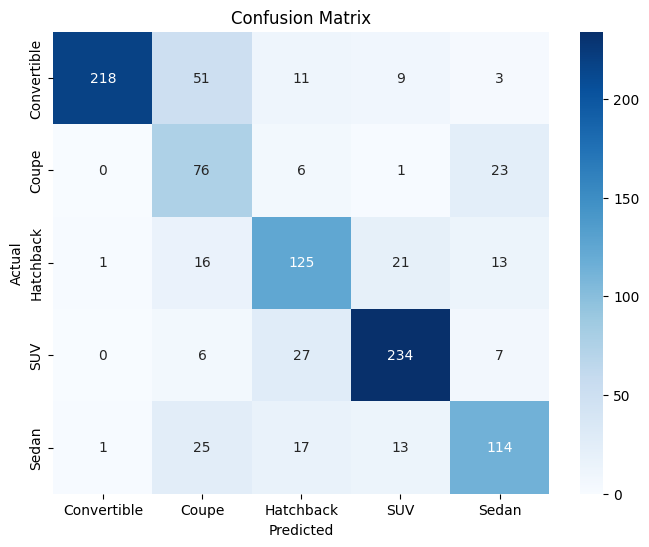

              precision    recall  f1-score   support

 Convertible       0.99      0.75      0.85       292
       Coupe       0.44      0.72      0.54       106
   Hatchback       0.67      0.71      0.69       176
         SUV       0.84      0.85      0.85       274
       Sedan       0.71      0.67      0.69       170

    accuracy                           0.75      1018
   macro avg       0.73      0.74      0.72      1018
weighted avg       0.79      0.75      0.76      1018



In [21]:
#confusion matrix
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

resnet.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in valid_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = resnet(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

class_names = train_dataset.classes  # gets the actual class names in correct order
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

print(classification_report(all_labels, all_preds, target_names=class_names))

In [22]:
for cls in train_dataset.classes:
    print(cls, len(os.listdir(f'car_dataset/Cars_Body_Type/train/{cls}')))

Convertible 811
Coupe 721
Hatchback 701
SUV 847
Sedan 729


Coupe has the least precision, meaning even the cars which are not coupe are mostly labeled as coupe.

This suggests the model has learned a Coupe decision boundary that is too broad, effectively over-predicting the class. A likely cause is feature-space overlap: Coupe shares structural characteristics with both Sedan (similar overall proportions, three-box-like rear in many models) and Convertible (sporty styling, low stance), unlike visually distinct classes such as SUV or Convertible-with-open-roof. Since the backbone was frozen during training, the model relied on generic ImageNet features rather than features fine-tuned specifically to distinguish car body types — these generic features may not capture the subtler structural cues needed to draw a tight boundary around Coupe, causing it to "absorb" borderline cases from neighboring classes.

**What I could have done better to increase the coupe precision?**

1. Unfreeze more of the backbone
2. More training epochs / training-set size for Coupe specifically
3. Hard-negative–aware data augmentation:

Since Coupe is being confused mainly with Sedan and Convertible, augmenting with rotations/crops that specifically emphasize the rear three-quarter view (where the trunk-lid-vs-hatch distinction is most visible) could help the model latch onto the actual discriminating feature, rather than overall silhouette which is genuinely similar between these classes.

In [25]:
print(train_dataset.classes)

['Convertible', 'Coupe', 'Hatchback', 'SUV', 'Sedan']


In [6]:
#prediction
import torch.nn.functional as F
from PIL import Image

class_names = ['Convertible', 'Coupe', 'Hatchback', 'SUV', 'Sedan']

def predict(image_path):
    image = Image.open(image_path).convert('RGB')
    img_tensor = transform(image).unsqueeze(0).to(device)

    resnet.eval()
    with torch.no_grad():
        output = resnet(img_tensor)
        probs = F.softmax(output, dim=1)[0]

    predicted_class = class_names[torch.argmax(probs).item()]

    print(f"Predicted: {predicted_class}")
    for i, cls in enumerate(class_names):
        print(f"  {cls}: {probs[i].item()*100:.2f}%")

    return predicted_class

In [7]:
from google.colab import files
uploaded = files.upload()

Saving suv.jpeg to suv.jpeg


In [37]:
image_path = list(uploaded.keys())[0]  # gets the filename you just uploaded
predict(image_path)

Predicted: SUV
  Convertible: 0.21%
  Coupe: 0.45%
  Hatchback: 1.34%
  SUV: 90.05%
  Sedan: 7.96%


'SUV'

In [5]:
#AFTER SESSION DISCONNECTS:

# 1. Reconnect to drive
from google.colab import drive
drive.mount('/content/drive')

# 2. Re-import everything needed
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models
import torchvision.transforms as transforms
from PIL import Image

# 3. Rebuild the exact same architecture
resnet = models.resnet18(weights=None)
resnet.fc = nn.Linear(512, 5)

# 4. Load your saved trained weights (map_location handles CPU/GPU mismatch)
resnet.load_state_dict(torch.load('/content/drive/MyDrive/car_classifier_resnet18.pth', map_location=torch.device('cpu')))

# 5. Set device and move model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
resnet = resnet.to(device)
resnet.eval()

# 6. Re-define transforms (same as training)
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

class_names = ['Convertible', 'Coupe', 'Hatchback', 'SUV', 'Sedan']

print("Model loaded successfully. Device:", device)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Model loaded successfully. Device: cpu


In [9]:
!pip install gradio -q

import gradio as gr

def predict_gradio(image):
    image = image.convert('RGB')
    img_tensor = transform(image).unsqueeze(0).to(device) #3d to 4d

    resnet.eval()
    with torch.no_grad():
        output = resnet(img_tensor)
        probs = F.softmax(output, dim=1)[0]

    return {class_names[i]: float(probs[i]) for i in range(len(class_names))}

demo = gr.Interface(
    fn=predict_gradio,
    inputs=gr.Image(type="pil"),
    outputs=gr.Label(num_top_classes=5),
    title="Car Body Type Classifier",
    description="Upload a car image to classify it as Convertible, Coupe, Hatchback, SUV, or Sedan."
)

demo.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://f8ad58e00968d8b75f.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


F.softmax(output, dim=1) gives you back something like [[0.02, 0.91, 0.0007, 0.004, 0.07]] — a list containing one list (the outer bracket = batch wrapper, inner bracket = the actual 5 values).
[0] reaches into that outer bracket and pulls out just the inner list — [0.02, 0.91, 0.0007, 0.004, 0.07] — removing the outer wrapper, leaving you with the actual 5 values directly.

In [39]:
#deploying to huggingface
!pip install huggingface_hub transformers